In [62]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as c
from astropy.io import fits
from scipy.integrate import simps
from astropy.table import Table
from scipy.optimize import curve_fit
from scipy.special import erf
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Palatino']})
rc('text', usetex=True)

In [63]:
def one_gaussian(x,x0,sigma,Amp):
    return Amp * np.exp(-(x-x0)**2/(2*sigma**2)) 
N=3
def multiple_gaussian(x,*popt):   #Here popt must have a length of 3N+1, where N is the number of components being fit. The last element is y0
		length = len(popt) 

		#Beginning the total gaussian sum
		total_gaussian = 0
		for i in range(int(N)):
			#There are three separate parameters to fit for each gaussian: a center, fwhm, and amplitude. 
			index0 = 3 * i
			#The individual gaussian 
			gauss = one_gaussian(x,popt[index0],popt[index0+1],popt[index0+2])
			#Adding the individual Gaussian to the total gaussian
			total_gaussian += gauss


		#Adding y offset
		#total_gaussian += popt[-1]

		return total_gaussian
def individual_gaussians(x,popt,extract_popt=False):

		#This function extracts individual gaussians from the popt vector from a multi-Gaussian fit.

		num_components = N
		gauss_list = []
		popt_list = []
		for i in range(num_components):
			index0 = 3 * i
			gauss = one_gaussian(x,popt[index0],popt[index0+1],popt[index0+2])
			gauss_list.append(gauss)

			popt_list.append([popt[index0],popt[index0+1],popt[index0+2]])

		

		if extract_popt:
			return popt_list
		else:
			return gauss_list
def integral_gaussian(x,a,b,*pars):


		#I am extracting out the integral of a gaussian over a finite range x in [a,b]

		x0,sigma,Amp = pars

		integral_multiplier = np.sqrt(np.pi) * Amp * sigma/(np.sqrt(2)) #This is the amplitude of the integral of a gaussian of the form Aexp(-(x-x0)^2/(2sigma^2))



		erf_stuff = erf((b-x0)/(sigma*np.sqrt(2))) - erf((a-x0)/(sigma*np.sqrt(2))) #Here I am taking the limits based on the Fundamental Theorem of Calculus

		integral = integral_multiplier * erf_stuff  # The final form, which includes the integral of the y offset, which is simply y0 * x over the range [a,b]
		return integral

    
def mask_range(arr,a,b,other_arrays=None):  #Mask an array from value a to b
    if a > b:
        a,b = b,a
    
    masked_arr = arr[(arr >= a) & (arr <= b)]
    if not other_arrays:
        return masked_arr
    if other_arrays:
        masked_arrays = []
        for ay in other_arrays:
            masked = ay[(arr >= a) & (arr <= b)]
        return masked_arr,masked
            

        
def BPT_NII_HII(x):
    return 0.61/(x-0.05)+1.3
def BPT_SII_HII(x):
    return 1.3 + 0.72/(x-0.32)
def BPT_NII_Seyfert(x):
    return 0.61/(x-0.47)+1.19
def BPT_SII_Seyfert(x):
    return 1.89 * x +1.3

In [64]:
def mask_out(x,regions):   #Masking out wavelength regions
    masks = []
    for region in regions:
        reg_min,reg_max = region
        
        mask = (x >= reg_min) & (x <= reg_max)
        masks.append(mask)
    
    string_func = ''
    for i in range(len(masks)):
        string_func+='masks[%d]' % i
        if i!= len(masks)-1:
            string_func+=','
    
    exec('mask_tot = np.logical_not('+string_func+')')
    return masks

In [206]:
fname = '../Data/mangadap-8257-12701-default.fits'    #Disk galaxy
#fname = '../Data/mangadap-8257-12704-default.fits.gz'    #Elliptical galaxy
fdat = fits.open(fname)

In [207]:
fname.split('-')[2]

'12701'

In [230]:
len(fdat)

27

In [231]:
fdat[1].header

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -64 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                   76                                                  
NAXIS2  =                   76                                                  
NAXIS3  =                   11                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
WCSAXES =                    3 / Number of coordinate axes                      
CRPIX1  =                 39.0 / Pixel coordinate of reference point            
CRPIX2  =                 39.0 / Pixel coordinate of reference point            
CRPIX3  =                  1.0 / Pixel coordinate of reference point            
PC1_1   =         -0.0001388

In [233]:
fdat['EMLINE_GFLUX'].header

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -64 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                   76                                                  
NAXIS2  =                   76                                                  
NAXIS3  =                   11                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
WCSAXES =                    3 / Number of coordinate axes                      
CRPIX1  =                 39.0 / Pixel coordinate of reference point            
CRPIX2  =                 39.0 / Pixel coordinate of reference point            
CRPIX3  =                  1.0 / Pixel coordinate of reference point            
PC1_1   =         -0.0001388

In [210]:
int_flux = fdat['EMLINE_GFLUX'].data
int_flux_mask = fdat['EMLINE_GFLUX_MASK'].data

flux_masked = int_flux[int_flux_mask]
masked_flux_dict = {}
masked_flux_dat = {}
for i in range(len(int_flux)):
    j = i+1
    if j < 10:
        header_string = 'C0'+str(j)
    else:
        header_string = 'C'+str(j)
        
    definition = fdat['EMLINE_GFLUX'].header[header_string]
    
    masked_flux_dict[definition] = int_flux[i]
    

In [211]:
masked_flux_dict.keys()

dict_keys(['OIId---3728', 'Hb-----4862', 'OIII---4960', 'OIII---5008', 'OI-----6302', 'OI-----6365', 'NII----6549', 'Ha-----6564', 'NII----6585', 'SII----6718', 'SII----6732'])

In [212]:
Ha = masked_flux_dict['Ha-----6564']
Hb = masked_flux_dict['Hb-----4862']
OIII = masked_flux_dict['OIII---5008']
SII_6718 = masked_flux_dict['SII----6718']
SII_6732 = masked_flux_dict['SII----6732']
NII = masked_flux_dict['NII----6585']

In [213]:
spaxlon = np.arange(-19.,19.,0.5)
spaxlat = np.arange(-19,19,0.5)


In [214]:
total_lon = np.zeros((len(Ha),len(Ha)))
total_lat = np.zeros((len(Ha),len(Ha)))
for i in range(len(Ha)):
    for j in range(len(Ha)):
        
        total_lat[i][j] = spaxlat[i]

       
        total_lon[i][j] = spaxlon[j]

In [215]:
additional_mask = Hb>=0

Ha_masked = Ha[additional_mask]
Hb_masked = Hb[additional_mask]
OIII_masked = OIII[additional_mask]
NII_masked = NII[additional_mask]
SII_6718_masked = SII_6718[additional_mask]
SII_6732_masked = SII_6732[additional_mask]

total_lon_masked = total_lon[additional_mask]
total_lat_masked = total_lat[additional_mask]

In [216]:
NII_Ha = np.log10(NII_masked) - np.log10(Ha_masked)
OIII_Hb = np.log10(OIII_masked) - np.log10(Hb_masked)
SII_6718_Ha = np.log10(SII_6718_masked) - np.log10(Ha_masked)
SII_6732_Ha = np.log10(SII_6732_masked) - np.log10(Ha_masked)

SII_Ha = np.log10(SII_6718_masked+SII_6732_masked) - np.log10(Ha_masked)

<ipython-input-216-e58fbff6c157>:1: RuntimeWarning: divide by zero encountered in log10
  NII_Ha = np.log10(NII_masked) - np.log10(Ha_masked)
<ipython-input-216-e58fbff6c157>:1: RuntimeWarning: invalid value encountered in subtract
  NII_Ha = np.log10(NII_masked) - np.log10(Ha_masked)
<ipython-input-216-e58fbff6c157>:2: RuntimeWarning: divide by zero encountered in log10
  OIII_Hb = np.log10(OIII_masked) - np.log10(Hb_masked)
<ipython-input-216-e58fbff6c157>:2: RuntimeWarning: invalid value encountered in subtract
  OIII_Hb = np.log10(OIII_masked) - np.log10(Hb_masked)
<ipython-input-216-e58fbff6c157>:3: RuntimeWarning: divide by zero encountered in log10
  SII_6718_Ha = np.log10(SII_6718_masked) - np.log10(Ha_masked)
<ipython-input-216-e58fbff6c157>:3: RuntimeWarning: invalid value encountered in subtract
  SII_6718_Ha = np.log10(SII_6718_masked) - np.log10(Ha_masked)
<ipython-input-216-e58fbff6c157>:4: RuntimeWarning: divide by zero encountered in log10
  SII_6732_Ha = np.log10(SII_6

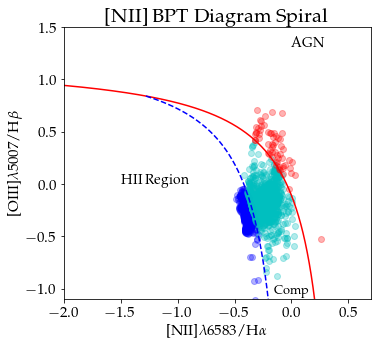

In [229]:
%matplotlib inline
plt.figure(figsize=(5.5,5))
xarr_dashed = np.linspace(-1.28,-0.1,len(OIII_Hb))
xarr_solid = np.linspace(-2.,0.315,len(OIII_Hb))

BPT_dashed = BPT_NII_HII(xarr_dashed)
BPT_solid = BPT_NII_Seyfert(xarr_solid)


HII_NII_mask = (OIII_Hb < 0.61/(NII_Ha-0.05)+1.3) & (NII_Ha < 0.)
Comp_NII_mask = (OIII_Hb > BPT_NII_HII(NII_Ha)) & (OIII_Hb < BPT_NII_Seyfert(NII_Ha))
AGN_NII_mask = (OIII_Hb > BPT_NII_Seyfert(NII_Ha))
#OIII_Hb = np.log10(N_OIII/N_Hb)
#NII_Ha = np.log10(N_NII/N_Ha)
#plt.plot(NII_Ha,OIII_Hb,'k^',alpha=0.3)
dist_from_center = np.sqrt(total_lon_masked**2+total_lat_masked**2)
#plt.scatter(NII_Ha,OIII_Hb,c='k',alpha=0.5,marker='o')
plt.scatter(NII_Ha[HII_NII_mask],OIII_Hb[HII_NII_mask],c='b',alpha=0.3)
plt.scatter(NII_Ha[Comp_NII_mask],OIII_Hb[Comp_NII_mask],c='c',alpha=0.3)
plt.scatter(NII_Ha[AGN_NII_mask],OIII_Hb[AGN_NII_mask],c='r',alpha=0.3)



plt.plot(xarr_solid,BPT_solid,'r-')
plt.plot(xarr_dashed,BPT_dashed,'b--')
plt.xlim(-2.,0.7)
plt.ylim(-1.1,1.5)



extra_AGN_mask = NII_Ha > 0.5

plt.xlabel(r'[NII]$\lambda6583$/H$\alpha$',fontsize=15)
plt.ylabel(r'[OIII]$\lambda5007$/H$\beta$',fontsize=15)

if fname.split('-')[2]=='12701':
    plt.text(-1.5,0.,'HII Region',fontsize=14)
    plt.text(-0.15,-1.05,'Comp',fontsize=13)
    plt.text(0.0,1.3,'AGN',fontsize=14)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
if fname.split('-')[2] == '12701':
    
    plt.title('[NII] BPT Diagram Spiral',fontsize=20)
    plt.savefig('NII_BPT_Spiral.pdf',bbox_inches='tight')
elif fname.split('-')[2] == '12704':
    
    plt.title('[NII] BPT Diagram Elliptical',fontsize=20)
    plt.scatter(NII_Ha[extra_AGN_mask],OIII_Hb[extra_AGN_mask],c='r',alpha=0.3)
    plt.xlim(-2.,1.8)
    plt.ylim(-1.8,2.3)
    
    plt.text(-1.5,-1.5,'HII Region',fontsize=14)
    plt.text(-0.15,-1.6,'Comp',fontsize=13)
    plt.text(0.0,1.7,'AGN',fontsize=14)
    plt.savefig('NII_BPT_Elliptical.pdf',bbox_inches='tight')
    
plt.show()

In [218]:
len(BPT_dashed)

5776

<ipython-input-219-0b41437fc826>:6: RuntimeWarning: divide by zero encountered in true_divide
  BPT_solid = 0.72 / (xarr_solid-0.32) + 1.3


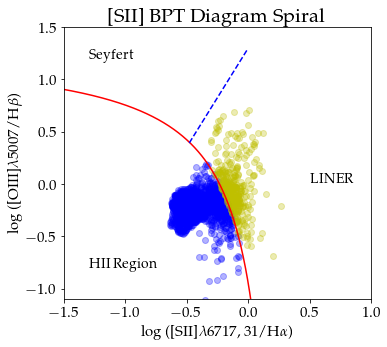

In [219]:
%matplotlib inline
plt.figure(figsize=(5.5,5))
xarr_dashed = np.linspace(-0.48,-0.01,1000)
xarr_solid = np.linspace(-2.,0.32,1000)

BPT_solid = 0.72 / (xarr_solid-0.32) + 1.3
BPT_dashed = 1.89 * xarr_dashed + 1.30

HII_SII_mask = ((OIII_Hb < 0.72 / (SII_Ha-0.32) + 1.3)) & (SII_Ha <0.1)
Seyfert_SII_mask = ((OIII_Hb > 0.72 / (SII_Ha-0.32) + 1.3)) & (OIII_Hb > 1.89 * SII_Ha + 1.30)
LINER_SII_mask = ((OIII_Hb > 0.72 / (SII_Ha-0.32) + 1.3)) & (OIII_Hb < 1.89 * SII_Ha + 1.30)
#LINER_SII_mask = LINER_SII_mask or (SII_6718_Ha > 0.3)
#OIII_Hb = np.log10(N_OIII/N_Hb)
#SII_6717_Ha = np.log10(N_SII_6717/N_Ha)
#SII_6731_Ha = np.log10(N_SII_6731/N_Ha)

plt.scatter(SII_Ha[HII_SII_mask],OIII_Hb[HII_SII_mask],c='b',alpha=0.3)
plt.scatter(SII_Ha[Seyfert_SII_mask],OIII_Hb[Seyfert_SII_mask],c='g',alpha=0.3)
plt.scatter(SII_Ha[LINER_SII_mask],OIII_Hb[LINER_SII_mask],c='y',alpha=0.3)


#plt.scat(SII_6732_Ha,OIII_Hb,'k^',alpha=0.3)
plt.plot(xarr_solid,BPT_solid,'r-')
plt.plot(xarr_dashed,BPT_dashed,'b--')

plt.xlabel(r'log ([SII]$\lambda6717,31$/H$\alpha$)',fontsize=15)
plt.ylabel(r'log ([OIII]$\lambda5007$/H$\beta$)',fontsize=15)


if fname.split('-')[2]=='12701':
    plt.text(-1.3,-0.8,'HII Region',fontsize=14)
    plt.text(0.5,0.0,'LINER',fontsize=14)

plt.text(-1.3,1.2,'Seyfert',fontsize=14)

plt.xlim(-1.5,1.)
plt.ylim(-1.1,1.5)

extra_LINER_mask = SII_Ha > 0.3

#plt.legend()
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
if fname.split('-')[2]=='12701':
    
    plt.title('[SII] BPT Diagram Spiral',fontsize=20)
    plt.savefig('SII_BPT_Spiral.pdf',bbox_inches='tight')
elif fname.split('-')[2]=='12704':
    
    plt.title('[SII] BPT Diagram Elliptical',fontsize=20)
    plt.scatter(SII_Ha[extra_LINER_mask],OIII_Hb[extra_LINER_mask],c='y',alpha=0.5)
    plt.xlim(-2.0,2.2)
    plt.ylim(-1.5,2.2)
    plt.text(-1.3,-1.3,'HII Region',fontsize=14)
    plt.text(0.5,1.7,'LINER',fontsize=14)
    plt.savefig('SII_BPT_Elliptical.pdf',bbox_inches='tight')

plt.show()

In [220]:
len(OIII_Hb[HII_SII_mask])+len(OIII_Hb[LINER_SII_mask])
#len(OIII_Hb[HII_NII_mask])+len(OIII_Hb[AGN_NII_mask])


2902

In [221]:
HII_tot_mask = HII_NII_mask & HII_SII_mask
Comp_mask = Comp_NII_mask
LINER_mask = LINER_SII_mask
Seyfert_mask = Seyfert_SII_mask

In [222]:
lat_HII,lon_HII = total_lat_masked[HII_NII_mask],total_lon_masked[HII_NII_mask]
lat_Comp,lon_Comp = total_lat_masked[Comp_NII_mask],total_lon_masked[Comp_NII_mask]
lat_AGN,lon_AGN = total_lat_masked[AGN_NII_mask],total_lon_masked[AGN_NII_mask]
#lat_LINER,lon_LINER = total_lat_masked[LINER_mask],total_lon_masked[LINER_mask]
#lat_Seyfert,lon_Seyfert = total_lat_masked[Seyfert_mask],total_lon_masked[Seyfert_mask]


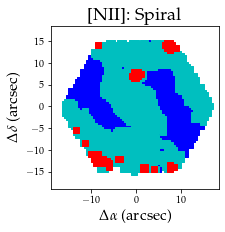

In [223]:
#plt.xlabel('Longitude relative to galactic center (spaxel)')
#plt.ylabel('Latitude relative to galactic center (spaxel)')
plt.figure(figsize=(3,3))
plt.scatter(lon_HII,lat_HII,c='b',marker='s',label=r'HII regions')
#plt.scatter(lat_LINER,lon_LINER,c='c',marker='s',label=r'LINER regions')
plt.scatter(lon_Comp,lat_Comp,c='c',marker='s',label=r'Composite regions')
plt.scatter(lon_AGN,lat_AGN,c='r',marker='s',label=r'AGN regions')

#plt.scatter(lat_Seyfert,lon_Seyfert,c='b',marker='s',label=r'Seyfert regions')
plt.xlim(xmin=np.min(total_lon),xmax=np.max(total_lon))
plt.ylim(ymin=np.min(total_lat),ymax=np.max(total_lat))

##plt.legend()

plt.xlabel(r'$\Delta\alpha$ (arcsec)',fontsize=15)
plt.ylabel(r'$\Delta\delta$ (arcsec)',fontsize=15)
if fname.split('-')[2] == '12701':
    plt.title('[NII]: Spiral',fontsize=18)
    plt.savefig('Spat_Res_BPT_NII_Spiral.pdf',bbox_inches='tight')
elif fname.split('-')[2] == '12704':
    plt.title('[NII]: Elliptical',fontsize=18)
    plt.savefig('Spat_Res_BPT_NII_Elliptical.pdf',bbox_inches='tight')
plt.show()


In [224]:
lat_HII,lon_HII = total_lat_masked[HII_SII_mask],total_lon_masked[HII_SII_mask]
lat_Seyfert,lon_Seyfert = total_lat_masked[Seyfert_SII_mask],total_lon_masked[Seyfert_SII_mask]
lat_LINER,lon_LINER = total_lat_masked[LINER_SII_mask],total_lon_masked[LINER_SII_mask]
#lat_LINER,lon_LINER = total_lat_masked[LINER_mask],total_lon_masked[LINER_mask]
#lat_Seyfert,lon_Seyfert = total_lat_masked[Seyfert_mask],total_lon_masked[Seyfert_mask]


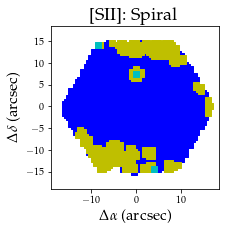

In [225]:
plt.figure(figsize=(3,3))
plt.scatter(lon_HII,lat_HII,c='b',marker='s',label=r'HII regions')
plt.scatter(lon_LINER,lat_LINER,c='y',marker='s',label=r'LINER regions')
#plt.scatter(lon_Comp,lat_Comp,c='g',marker='s',label=r'Composite regions')
#plt.scatter(lon_AGN,lat_AGN,c='c',marker='s',label=r'AGN regions')

plt.scatter(lon_Seyfert,lat_Seyfert,c='c',marker='s',label=r'Seyfert regions')
plt.xlim(xmin=np.min(total_lon),xmax=np.max(total_lon))
plt.ylim(ymin=np.min(total_lat),ymax=np.max(total_lat))

#plt.legend()
plt.xlabel(r'$\Delta\alpha$ (arcsec)',fontsize=15)
plt.ylabel(r'$\Delta\delta$ (arcsec)',fontsize=15)

if fname.split('-')[2] == '12701':
    plt.title('[SII]: Spiral',fontsize=18)
    plt.savefig('Spat_Res_BPT_SII_Spiral.pdf',bbox_inches='tight')
elif fname.split('-')[2] == '12704':
    plt.title('[SII]: Elliptical',fontsize=18)
    plt.savefig('Spat_Res_BPT_SII_Elliptical.pdf',bbox_inches='tight')

    

plt.show()


In [226]:
import numpy as np
quarterdeck = np.array([2,3,4,5,6,7,8,9,10,10,10,10,11])
deck = []
for i in range(4):
    deck.append(quarterdeck)

deck = np.array(deck)
deck = deck.flatten('F')

six_decks = []
for i in range(6):
    six_decks.append(deck)

six_decks = np.array(six_decks)
six_decks = six_decks.flatten('F')

In [227]:
stack = np.random.shuffle(six_decks)

In [50]:
stack1 = six_decks.tolist()
stack = np.random.shuffle(stack1)

In [51]:
import random
arr = np.arange(10)
random.shuffle(arr)
arr

array([8, 4, 6, 1, 2, 3, 0, 5, 9, 7])

In [52]:
random.sample(six_decks,len(six_decks))

TypeError: Population must be a sequence or set.  For dicts, use list(d).

In [53]:
six_decks

array([11,  6,  3, 10,  2, 10, 11, 10,  4,  9, 11,  3, 10,  2,  6,  9,  7,
        2, 10, 10, 11,  5, 10,  7,  4,  6,  9,  3, 10,  7,  6,  4,  5, 10,
        2,  3,  8, 10,  8,  6, 10,  2,  4,  4,  5, 10, 11, 10,  5,  5,  8,
        7,  3,  2,  9, 10,  4,  4, 10,  3,  7,  6,  9,  8, 11,  8,  3,  4,
        2, 10,  9,  6,  2, 10, 11, 10, 10,  7,  6, 10,  3,  7,  6, 10,  9,
       10,  9, 10,  6,  6,  7,  4, 10,  8,  6, 10, 10,  5, 10,  7, 11,  9,
       11,  2,  3,  6,  3,  8,  8, 10,  8, 10,  8, 10,  9, 10,  4,  8,  7,
       10,  2, 10, 10,  5,  5,  4,  4,  7, 10,  9, 11, 10,  6, 11,  8,  3,
       10,  2,  8,  9, 10, 10,  6,  4,  7,  3,  7,  9, 10, 10, 10,  3,  9,
        5,  5,  6, 10, 11,  3, 10, 10,  3, 10, 10,  7,  8,  8, 11, 10, 11,
        7, 10,  9, 10,  6,  3, 10,  8, 11,  6,  5,  9, 11,  8,  6, 10,  7,
       10,  5,  4, 10, 10,  3,  5, 10,  5,  5,  2,  5,  4,  8, 11,  4,  2,
        2, 10,  5,  7,  2,  4, 10, 10,  2, 10,  4,  5,  6, 10,  7, 10,  2,
       10, 10,  9,  2,  8

In [61]:
endpoint = int(np.random.normal(52,8)) #Dealer guesstimating where to end the shoe at the end of the shuffle
#She tries to end the shoe about one deck before the end

In [60]:
n=0  #Index of which card in the deck it is
shoe = six_decks
#Random player

dealer_wins = 0
player_wins = 0
while n < (len(shoe)-endpoint):   #Where the dealer puts the yellow card in the shoe
    
    dealer_cards = []
    player_cards = []
    
    #Initial dealing
    for i in range(2):
        player_cards.append(shoe[n])
        n+= 1
        dealer_cards.append(shoe[n])
        n+=1
    
    if (sum(dealer_cards) == 21 and sum(player_cards != 21)):    #peeking for a blackjack
        dealer_wins += 1
    elif (sum(player_cards)==21 and sum(dealer_cards != 21)):    #Player blackjack
        player_wins += 1.5  #3 to 2 payout
    elif (sum(dealer_cards) == 21 and sum(player_cards == 21)):  #both player and dealer blackjack
        #Push
        dealer_wins += 0
        player_wins += 0
    
        
        
    
    else:
        continue_ = False
        
        if sum(player_cards) < 16:
            continue_ = True
        elif sum(player_cards) > 16:
            continue_ = False
            
        while continue_:
            player_cards.append(shoe[n])
            n+=1
            if sum(player_cards) < 16:
                continue_ = True
            elif (sum(player_cards) > 16) and (11 not in player_cards):
                continue_ = False
            elif ()
        
        
        
    
    
    
    
    
    
    
    
    
    

SyntaxError: unexpected EOF while parsing (<ipython-input-60-73527648cc6a>, line 1)